<a href="https://colab.research.google.com/github/DiyaBatra/diya-batra-3b8b4031a/blob/main/firedetection_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/dataset/Industrial fire dataset.zip"
extract_path = "/content/fire_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")

Done


In [6]:
import os, shutil

base_path = "/content/fire_dataset/Industrial fire dataset/data/train"
output_path = "/content/final_dataset"

os.makedirs(f"{output_path}/fire", exist_ok=True)
os.makedirs(f"{output_path}/non_fire", exist_ok=True)

img_dir = f"{base_path}/images"
label_dir = f"{base_path}/labels"

for img in os.listdir(img_dir):
    img_path = os.path.join(img_dir, img)
    label_file = img.replace(".jpg", ".txt")
    label_path = os.path.join(label_dir, label_file)

    if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
        shutil.copy(img_path, f"{output_path}/fire")
    else:
        shutil.copy(img_path, f"{output_path}/non_fire")

print("Dataset Ready ✅")

Dataset Ready ✅


In [8]:
print(os.listdir(dataset_path))

NameError: name 'dataset_path' is not defined

In [10]:
import os

dataset_path = "/content/final_dataset"

print(os.listdir(dataset_path))

['non_fire', 'fire']


In [12]:
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import ResNet50, InceptionV3, MobileNetV2, DenseNet121, VGG16

In [15]:
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import ResNet50, InceptionV3, MobileNetV2, DenseNet121, VGG16


# Correct the dataset_path to point to the actual directory containing class folders

dataset_path = "/content/final_dataset"

img_size = (224,224)
batch_size = 32
num_classes = 2
seed = 42

image_paths = []
labels = []

class_names = sorted(os.listdir(dataset_path))

for label, class_name in enumerate(class_names):
    folder = os.path.join(dataset_path, class_name)
    for img_file in os.listdir(folder):
        image_paths.append(os.path.join(folder, img_file))
        labels.append(label)

print(f"Total images: {len(image_paths)}")
print(f"Classes: {class_names}")

from sklearn.model_selection import train_test_split

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.30, stratify=labels, random_state=seed)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=seed)


Total images: 14122
Classes: ['fire', 'non_fire']


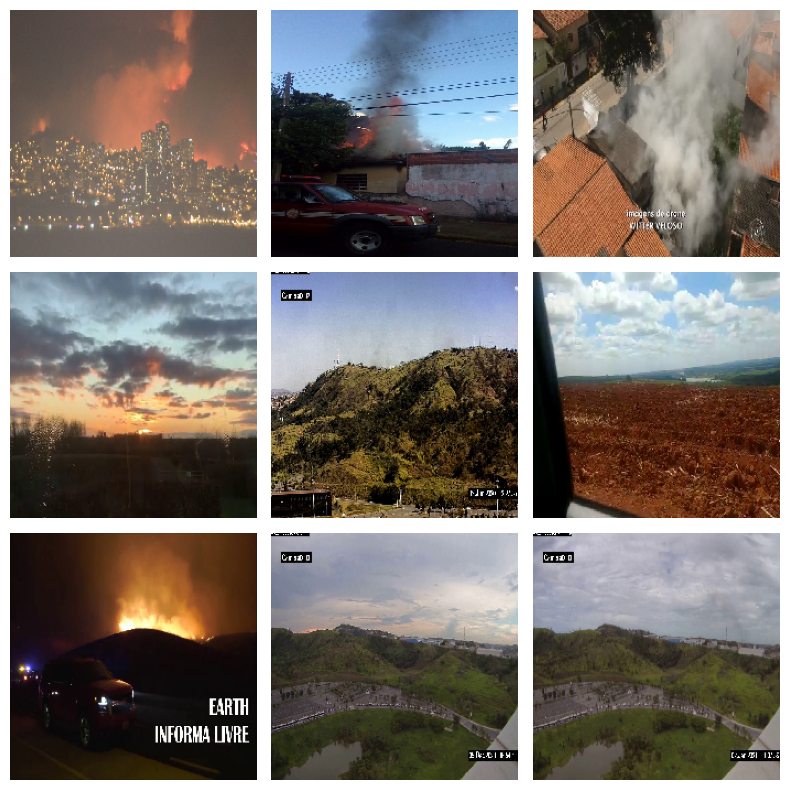

In [17]:
import random

plt.figure(figsize=(8,8))

sample_indices = random.sample(range(len(image_paths)), 9)

for i, idx in enumerate(sample_indices):
    img = tf.keras.preprocessing.image.load_img(image_paths[idx], target_size=(224,224))
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = image / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels)).map(load_image).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels)).map(load_image).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels)).map(load_image).batch(batch_size)

In [21]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

train_ds = train_ds.map(lambda x,y: (data_aug(x, training=True), y))

In [27]:
def build_model(base_model_class, name):

    base_model = base_model_class(weights="imagenet", include_top=False, input_shape=(224,224,3))
    base_model.trainable = True

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.3)(x)
    output = Dense(1, activation="sigmoid")(x) # Corrected: Call the Dense layer with 'x'

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="binary_crossentropy", # Corrected: Use binary_crossentropy for sigmoid output
        metrics=["accuracy"]
    )

    print(name, "Params:", model.count_params())
    return model

In [25]:
from tensorflow.keras import layers

def build_vit():

    inputs = layers.Input(shape=(224,224,3))
    x = layers.Conv2D(64, 3, activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=Adam(0.0001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    print("ViT Params:", model.count_params())
    return model

In [1]:
models = {
    "MobileNetV2": MobileNetV2
}

results = {}

for name, model_class in models.items():

    print("\nTraining:", name)

    model = build_model(model_class, name)

    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=5)
    end = time.time()

    results[name] = {
        "model": model,
        "history": history,
        "time": end-start
    }

# Train ViT
vit_model = build_vit()
history = vit_model.fit(train_ds, validation_data=val_ds, epochs=20)

results["ViT"] = {"model": vit_model, "history": history}


NameError: name 'MobileNetV2' is not defined

In [3]:
history = results["MobileNetV2"]["history"]

print(history.history['val_accuracy'])

NameError: name 'results' is not defined

In [5]:
model = build_model(MobileNetV2, "MobileNetV2")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2
)

NameError: name 'build_model' is not defined

In [7]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2

In [9]:
import os

dataset_path = "/content/final_dataset"

img_size = (224,224)
batch_size = 32
seed = 42

image_paths = []
labels = []

class_names = sorted(os.listdir(dataset_path))

for label, class_name in enumerate(class_names):
    folder = os.path.join(dataset_path, class_name)
    for img_file in os.listdir(folder):
        image_paths.append(os.path.join(folder, img_file))
        labels.append(label)

In [11]:
from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=seed
)

In [13]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    image = image / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels)).map(load_image).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels)).map(load_image).batch(batch_size)

In [15]:
def build_model(base_model_class, name):

    base_model = base_model_class(weights="imagenet", include_top=False, input_shape=(224,224,3))
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.3)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [17]:
model = build_model(MobileNetV2, "MobileNetV2")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2
)

Epoch 1/2
354/354 ━━━━━━━━━━━━━━━━━━━━ 690s 2s/step - accuracy: 0.5830 - loss: 0.6960 - val_accuracy: 0.7023 - val_loss: 0.5785
Epoch 2/2
354/354 ━━━━━━━━━━━━━━━━━━━━ 709s 2s/step - accuracy: 0.6920 - loss: 0.5845 - val_accuracy: 0.7388 - val_loss: 0.5226


In [19]:
history = model.fit(train_ds, validation_data=val_ds, epochs=1)

354/354 ━━━━━━━━━━━━━━━━━━━━ 684s 2s/step - accuracy: 0.7440 - loss: 0.5088 - val_accuracy: 0.7696 - val_loss: 0.4738


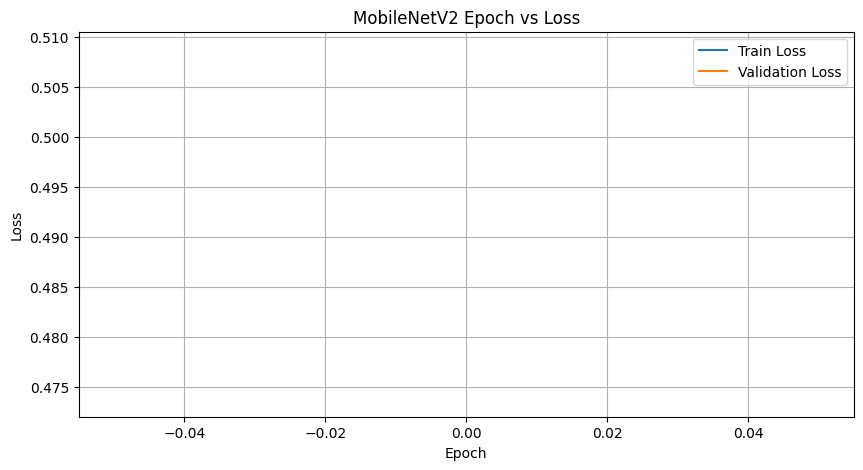

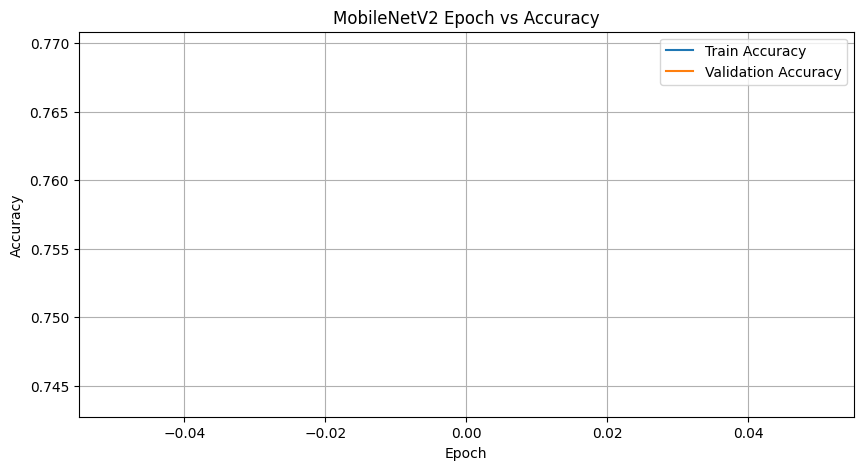

In [27]:
import matplotlib.pyplot as plt

# Fix: Define the 'results' dictionary and populate it with the available history.
# The 'history' variable from previous cell executions (KWF8TDkDwH2n and iXjM5iEC1lJ6) holds the MobileNetV2 training history.
results = {
    "MobileNetV2": {
        "model": model, # Add the model object
        "history": history # Use the existing 'history' object
    }
}

for name, res_data in results.items():
    model_history = res_data["history"]

    # Plot Training and Validation Loss
    plt.figure(figsize=(10, 5))
    plt.plot(model_history.history['loss'], label='Train Loss')
    plt.plot(model_history.history['val_loss'], label='Validation Loss')
    plt.title(name + " Epoch vs Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Training and Validation Accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(model_history.history['accuracy'], label='Train Accuracy')
    plt.plot(model_history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(name + " Epoch vs Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

89/89 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step


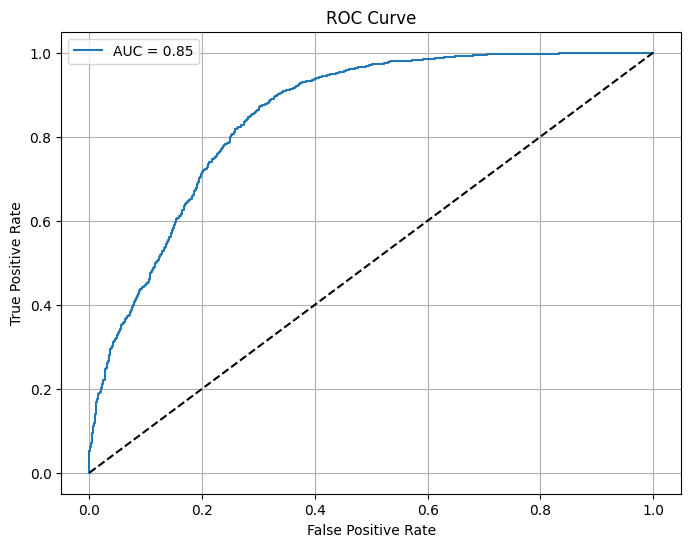

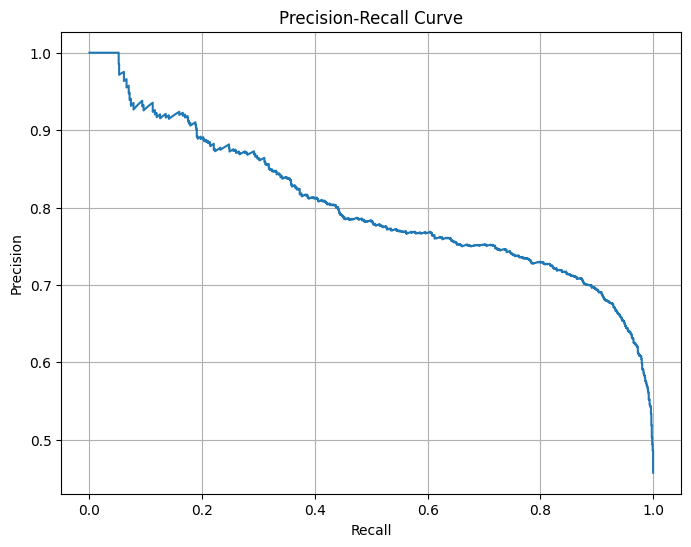

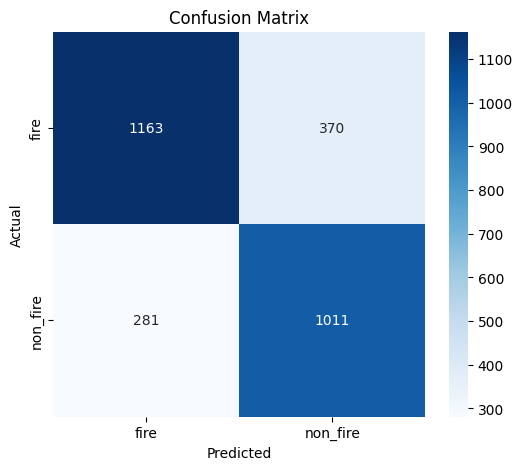

Classification Report:

              precision    recall  f1-score   support

        fire       0.81      0.76      0.78      1533
    non_fire       0.73      0.78      0.76      1292

    accuracy                           0.77      2825
   macro avg       0.77      0.77      0.77      2825
weighted avg       0.77      0.77      0.77      2825



In [29]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, classification_report

# Use validation dataset instead of test_ds
model = results["MobileNetV2"]["model"]

# True labels
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Predictions
preds = model.predict(val_ds)
y_pred = (preds > 0.5).astype(int).flatten()

# ===================== ROC CURVE =====================
fpr, tpr, _ = roc_curve(y_true, preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# ===================== PRECISION-RECALL CURVE =====================
precision, recall, _ = precision_recall_curve(y_true, preds)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

# ===================== CONFUSION MATRIX =====================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ===================== CLASSIFICATION REPORT =====================
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

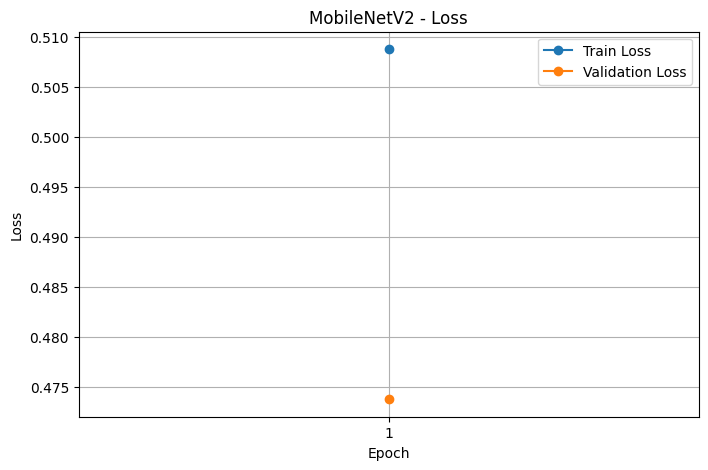

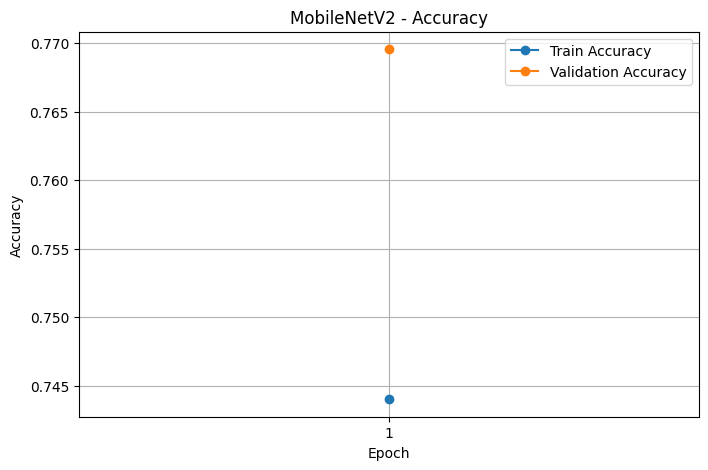

In [31]:
for name, res_data in results.items():
    model_history = res_data["history"]

    loss = model_history.history['loss']
    val_loss = model_history.history['val_loss']
    acc = model_history.history['accuracy']
    val_acc = model_history.history['val_accuracy']

    epochs_range = range(1, len(loss) + 1)

    # 🔹 Loss Graph
    plt.figure(figsize=(8,5))
    plt.plot(epochs_range, loss, marker='o', label='Train Loss')
    plt.plot(epochs_range, val_loss, marker='o', label='Validation Loss')
    plt.title(name + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(epochs_range)
    plt.legend()
    plt.grid(True)
    plt.show()

    # 🔹 Accuracy Graph
    plt.figure(figsize=(8,5))
    plt.plot(epochs_range, acc, marker='o', label='Train Accuracy')
    plt.plot(epochs_range, val_acc, marker='o', label='Validation Accuracy')
    plt.title(name + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(epochs_range)
    plt.legend()
    plt.grid(True)
    plt.show()

In [33]:
print(len(history.history['loss']))

1


In [35]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2
)

Epoch 1/2
354/354 ━━━━━━━━━━━━━━━━━━━━ 667s 2s/step - accuracy: 0.7810 - loss: 0.4553 - val_accuracy: 0.7961 - val_loss: 0.4383
Epoch 2/2
354/354 ━━━━━━━━━━━━━━━━━━━━ 649s 2s/step - accuracy: 0.7830 - loss: 0.4511 - val_accuracy: 0.7993 - val_loss: 0.4301


In [37]:
results = {
    "MobileNetV2": {
        "model": model,
        "history": history
    }
}

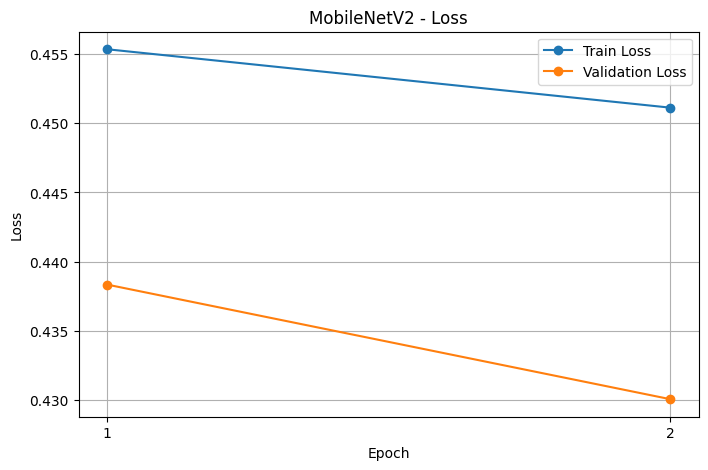

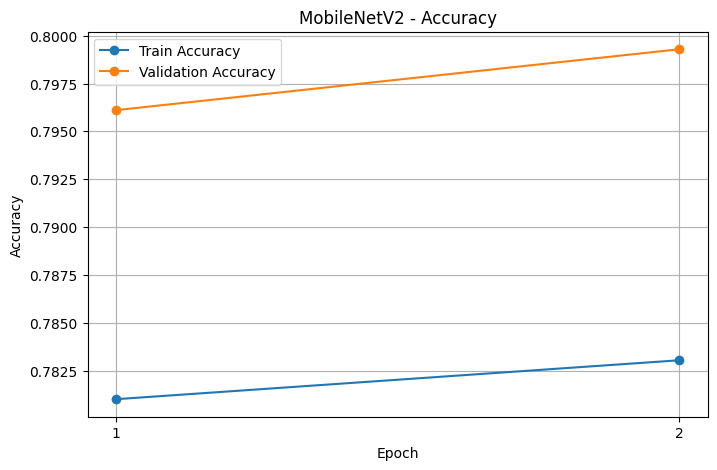

In [38]:
for name, res_data in results.items():
    model_history = res_data["history"]

    loss = model_history.history['loss']
    val_loss = model_history.history['val_loss']
    acc = model_history.history['accuracy']
    val_acc = model_history.history['val_accuracy']

    epochs_range = range(1, len(loss) + 1)

    # 🔹 Loss Graph
    plt.figure(figsize=(8,5))
    plt.plot(epochs_range, loss, marker='o', label='Train Loss')
    plt.plot(epochs_range, val_loss, marker='o', label='Validation Loss')
    plt.title(name + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(epochs_range)
    plt.legend()
    plt.grid(True)
    plt.show()

    # 🔹 Accuracy Graph
    plt.figure(figsize=(8,5))
    plt.plot(epochs_range, acc, marker='o', label='Train Accuracy')
    plt.plot(epochs_range, val_acc, marker='o', label='Validation Accuracy')
    plt.title(name + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(epochs_range)
    plt.legend()
    plt.grid(True)
    plt.show()